# Projeto IIA

Grupo AQ

- Juniper Wilson 61795
- Jaime Sousa 58171
- Miguel Zhang 61829

Contribuições do grupo:

- Juniper 10 hours, 33%, did the data preprocessing, worked some on feature selection to split Cabin into 3 features, and solved problem O2
- Jaime 33%
- Miguel 33%

## Estrategia

Reparem no seguinte acerca dos problemas:

Um de classificação: 
O1

Outros dois de regressão:
O2 e O3

O objetivo O4 é resolvido no notebook da TP08: Feature selection

O nosso metodo de trabalho deve passar por:

1) Induzir os dados ausentes (Data Imputing)
2) Reduzir as features triviais usando Spearman (Feature Selection)
3) Construir classificadores/regressores demonstrados nas tps
4) Pontuar e escolher os classificadores
5) Otimizando os seus hyperparametros

In [1]:

import sys
from pathlib import Path

# Make project root importable regardless of notebook working directory
cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from sklearn.feature_selection import SequentialFeatureSelector 
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVC
from sklearn.svm import LinearSVR
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

# Scikit-learn: model selection
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Scikit-learn: metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import r2_score
from sklearn.metrics import recall_score
from sklearn.metrics import root_mean_squared_error

# Our methods
from src.load import load_spaceship_data


## Preprocessing
For preprocessing on the classification problem O1, we only did imputation of the missing values, since scaling is not strictly necessary for our implementation using Decision Trees

For preprocessing on the regression problems O2 and 03, we started by standardizing the numeric columns, and then imputing missing values with KNNImputer for the numeric columns and SimpleImputer with the most frequent value as the strategy. The boxplots generated when running the regression preprocessing cell shows that the bulk of the values of each features are concentrated between about -1 and 10, ideal for the regression models we used.
### Scaling 
I (Juniper) decided to use standardization to scale the data rather than the other techniques because I created box plots of the data and noticed that the data was not evenly distributed in it's range and had lots of outliers. When I first attempted to use normalization as a scaling method, the outliers compressed the bulk of the data into just a tiny sliver of the range, which might result in lost precision due to floating point errors. Therefore I decided on standardization. 
### Imputing
As far as imputing the missing values, two different methods had to be used because some of the columns are numerical and others are categorical. I decided on KNN imputation because it is multivariate. I thought this data set would benefit from a multivariate technique, because all the features must be taken into account to determine the transported passengers, and a univariate method might miss out on some of the hidden complexities. For the categorical columns I used the simpler SimpleImputer because it's "most_frequent" strategy works well for categorical data.

In [2]:
import load as load_module

#path
data_path = "../data/spaceship_data.csv"

raw_df = load_module.load_spaceship_data_as_df(data_path)

# I split the data frame into numerical and categorical columns, so that each can be scaled and imputted appropriately.
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
categorical_cols = ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']

In [3]:
# Preprocessing for classification problem
import preprocessing as preprocessing_module

numerical_df = raw_df.loc[:, numerical_cols]
categorical_df = raw_df.loc[:, categorical_cols]

df_classification = preprocessing_module.impute(numerical_cols, categorical_cols, numerical_df, categorical_df)

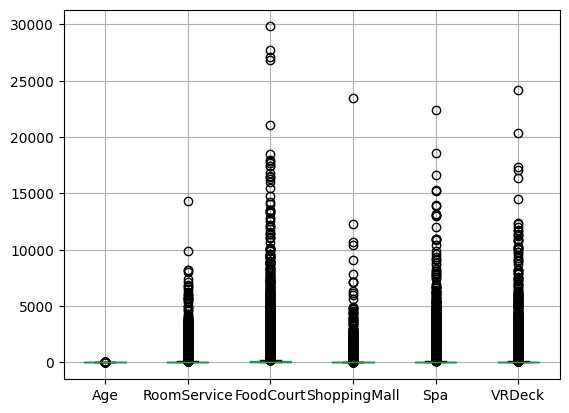

In [4]:
import pandas as pd

def preprocess_regression(raw_df: pd.DataFrame) -> pd.DataFrame:
    # Preprocessing for regression problems
    numerical_df = raw_df.loc[:, numerical_cols]
    categorical_df = raw_df.loc[:, categorical_cols]

    standardized_df = preprocessing_module.standardize(numerical_cols, categorical_cols, numerical_df, categorical_df)

    numerical_df = standardized_df.loc[:, numerical_cols]
    categorical_df = standardized_df.loc[:, categorical_cols]

    df_regression = preprocessing_module.impute(numerical_cols, categorical_cols, numerical_df, categorical_df)

    df_regression.boxplot()
    return df_regression

df_regression = preprocess_regression(raw_df)

## Feature Selection (O4)

Decidimos utilizar seleção de variaveis para acelerar o treino das nossas maquinas de aprendizagem. Tomamos essa decisão por acreditar que certas variaveis como, por exemplo, o ID não estivessem relacionadas com as targets. 

Usaremos a correlação Spearman para confirmar as nossas suspeitas e descobrir que variaveis são mais importantes para os problemas.

Acreditamos também que nesta consideração conseguimos responder à questão O4:  Quais  são  os  atributos  mais  importantes  nos  modelos O1, O2, O3?

### Cabin Feature
Since we determined that the passenger's cabin is one of the more important features for O2 and O3, I thought it might be interesting to split the feature into 3 features. These new features are "Deck", "Room", and "Starboard", I simply split the original "Cabin" feature and represented the first part as a number and a boolean for the side of the ship. This gives me the additional advantage of these new features not being categorical, allowing me to use a DecisionTreeRegressor which I suspected might work well.

In [5]:
import pandas as pd
def split_cabin_feature(df_regression: pd.DataFrame)-> pd.DataFrame:
    # This is the code to create the new features
    import pandas as pd
    cabin_dict_reg = {
        'Deck': [],
        'Room': [],
        'Starboard': []
    }

    # Deck Represents the index of the letter of the deck (A = 1), the room number stays the same, 
    # Starboard is a boolean to see if the cabin is on the side of the ship "S"
    for value in df_regression['Cabin']:
        cabin_info = value.split('/')
        cabin_dict_reg["Deck"].append(ord(cabin_info[0]) - 64)
        cabin_dict_reg["Room"].append(int(cabin_info[1]))
        cabin_dict_reg["Starboard"].append(cabin_info[2] == "S")

    cabin_df_reg = pd.DataFrame(cabin_dict_reg)
    df_regression = df_regression.join(cabin_df_reg)
    df_regression = df_regression.drop(columns = ['Cabin'])
    return df_regression

df_regression = split_cabin_feature(df_regression)

In [6]:
# O4.1: Spearman correlation for O1, O2 and O3 using load.py
import importlib
from spearman import spearman_with_target

# O1: classification target
spearman_o1 = spearman_with_target(df_classification, "Transported")
print("O1: Spearman Correlation with Target Transported:")
print(spearman_o1)
print("\n")

# O2: regression target
spearman_o2 = spearman_with_target(df_regression, "FoodCourt")
print("O2: Spearman Correlation with Target FoodCourt:")
print(spearman_o2)
print("\n")

# O3: regression target, filtered to passengers that were transported
spearman_o3 = spearman_with_target(df_regression, "Age", filter_col="Transported", filter_value=True)
print("O3: Spearman Correlation with Target Age (Transported=True only):")
print(spearman_o3)
print("\n")

print("Low correlation means the feature is not strongly related to the target. Consider dropping it.")

O1: Spearman Correlation with Target Transported:
              correlation        p_value
CryoSleep        0.458955   0.000000e+00
RoomService     -0.373009  1.743190e-228
Spa             -0.370479  3.468374e-225
VRDeck          -0.350642  2.444867e-200
ShoppingMall    -0.231895   1.481901e-85
FoodCourt       -0.181094   2.417917e-52
HomePlanet       0.138180   5.426828e-31
Destination     -0.101958   1.554600e-17
Age             -0.056877   2.074665e-06
Cabin           -0.056653   2.275076e-06
VIP             -0.033039   5.862320e-03
Name            -0.016093   1.796545e-01
PassengerId      0.013858   2.479049e-01
Transported           NaN            NaN


O2: Spearman Correlation with Target FoodCourt:
              correlation        p_value
CryoSleep       -0.532058   0.000000e+00
VRDeck           0.513728   0.000000e+00
Spa              0.487398   0.000000e+00
Deck            -0.277693  2.467963e-123
Age              0.199001   4.809285e-63
ShoppingMall     0.192125   8.285182e-5

/home/juniper/Documents/Schoo/IIA/thirdyear/aai/src/spearman.py:67: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.spearmanr(series, y_s)


### Conclusão

Dadas as baixas correlações, decidimos dropar as colunas:

O1: PassengerId, Name

O2: PassengerId, RoomService, Starboard, ShoppingMall, Name

O3: CryoSleep, PassengerId, Name, Destination

*Obs: Dropa-se também Transported em O3 dada a natureza do problema*


In [7]:
import pandas as pd

# O1: Drop PassengerId and Name
df_o1 = df_classification.drop(columns=["PassengerId", "Name"])

# O2: Drop PassengerId, Name, Destination, HomePlanet
df_o2 = df_regression.drop(columns=["PassengerId", "RoomService", "Starboard", "ShoppingMall", "Name"])

# O3: Filter to Transported=True, then drop PassengerId, Name, Destination, CryoSleep, Transported
df_o3 = df_regression[df_regression["Transported"] == True].drop(columns=["PassengerId", "Name", "Destination", "CryoSleep", "Transported"])

#### Resposta à Questão O4

Concluimos também que as variaveis mais importantes as com uma correlação maior com a target são as seguintes, por ordem decrescente de importância:

O1: CryoSleep, RoomService, Spa, VRDeck

O2: Deck, VRDeck, Spa, Room, CryoSleep

O3: Deck, FoodCourt, Spa, VRDeck, ShoppingMall

#### Observação adicional O3

As correlações mais baixas em O3 sugerem que não é possivel prever com tanta previsibilidade a target Age como nos outros problemas 

# Exemplo de um classificador

In [8]:
# Load the raw data
import importlib
import sys
from pathlib import Path

import pandas as pd

# Make project root importable regardless of notebook working directory
cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.statistics import present_classification_statistics
import src.load as load_module
importlib.reload(load_module)

raw_df = load_module.load_spaceship_data_as_df(str(project_root / "data" / "spaceship_data.csv"))
y = raw_df["Transported"].astype(int)
X = raw_df.drop(columns=["Transported", "PassengerId", "Name"], errors='ignore')

# Basic preprocessing so the tree can train on numeric data
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode().iloc[0])

X = pd.get_dummies(X, drop_first=True)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Train DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Print metrics
present_classification_statistics(y_test, y_pred)

=== DECISION TREE CLASSIFIER METRICS ===

Confusion Matrix:
[[486 230]
 [113 562]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74       716
           1       0.71      0.83      0.77       675

    accuracy                           0.75      1391
   macro avg       0.76      0.76      0.75      1391
weighted avg       0.76      0.75      0.75      1391

Precision: 0.7619737501198814
Recall: 0.7534148094895758
F1-Score: 0.7522782018326476
Matthews Correlation Coefficient: 0.5161336297331891


# Problema de Classificação:

## O1:  Prever  a  variável  Transported  dados  os  atributos  do  dataset fornecido


### Solution

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from src.statistics import best_model_simple

df_o1 = df_o1.sample(n=min(100, len(df_o1)), random_state=42).reset_index(drop=True)

y = df_o1["Transported"].astype(int)
X = df_o1.drop(columns=["Transported"], errors="ignore")

# Convert string categories like Earth, Mars and Europa into numeric features
X = pd.get_dummies(X, drop_first=True)

#splits the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Instantiate classifiers
knn_clf = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
linear_svc = LinearSVC(max_iter=10000, random_state=42).fit(X_train, y_train)
svc_clf = SVC(probability=True, random_state=42).fit(X_train, y_train)
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, y_train)

#chat dont erase these lines, they are needed for the next step

models = [knn_clf, linear_svc, svc_clf, dt_clf]

# Não usar r2_score para classificação, usar f1_score ou accuracy_score
best_model_name, best_model_score = best_model_simple(models, X_test, y_test)
print("Best model (simple):", best_model_name, best_model_score)

# quick check
print('Created classifiers:', knn_clf, linear_svc, svc_clf, dt_clf)

Best model (simple): LinearSVC 0.5833333333333334
Created classifiers: KNeighborsClassifier() LinearSVC(max_iter=10000, random_state=42) SVC(probability=True, random_state=42) DecisionTreeClassifier(max_depth=10, random_state=42)


/home/juniper/Documents/Schoo/IIA/venvs/ai_spaceship_venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/juniper/Documents/Schoo/IIA/thirdyear/aai/src/statistics.py:78: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, pval = pearsonr(truth, preds)


## O2: Prever  o  valor  dispendido  pelos  passageiros  em  restaurantes (variável FoodCourt) 
### Solution

Decision Tree
R2: 0.5328
RMSE: 1161.7627
Correlation Score: 0.7480 (p-value=2.894585e-08)
Maximum Error: 5684.7500
Mean Absolute Error: 420.2421

KNN
R2: 0.1072
RMSE: 1605.9943
Correlation Score: 0.3329 (p-value=3.584761e-02)
Maximum Error: 9036.6444
Mean Absolute Error: 567.7272

Random Forest
R2: 0.2957
RMSE: 1426.4281
Correlation Score: 0.5674 (p-value=1.345117e-04)
Maximum Error: 8174.6753
Mean Absolute Error: 531.7633



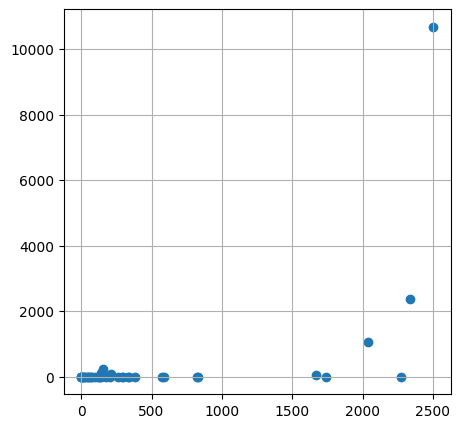

Best model (simple): DecisionTreeRegressor 0.5328176152084099


In [10]:
# O2 analysis (see O4.1 for Spearman correlations)
import matplotlib.pyplot as plt
from src.statistics import best_model_simple, present_simple_statistics
from sklearn import tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

df_o2 = df_o2.sample(n=min(200, len(df_o2)), random_state=42).reset_index(drop=True)

y = df_o2["FoodCourt"]
X = df_o2.drop(columns=["FoodCourt"], errors="ignore")
X = pd.get_dummies(X, drop_first=True)
X = X.reindex(sorted(X.columns), axis=1)

# Splits the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Models to train 
tree_reg = tree.DecisionTreeRegressor(min_samples_split=6).fit(X_train, y_train)
knn_reg = KNeighborsRegressor(n_neighbors = 9).fit(X_train, y_train)
rand_reg = RandomForestRegressor(min_samples_split=6).fit(X_train, y_train)

# Displays the stats for each model
print("Decision Tree")
preds=tree_reg.predict(X_test)
present_simple_statistics(y_test, preds)

print("KNN")
preds=knn_reg.predict(X_test)
present_simple_statistics(y_test, preds)

print("Random Forest")
preds=rand_reg.predict(X_test)
present_simple_statistics(y_test, preds)

plt.figure(figsize=(5,5))
plt.scatter(preds, y_test)
plt.grid()
plt.show()

# Figure out best model
models = [tree_reg, knn_reg, rand_reg]
best_model_name, best_model_score = best_model_simple(models, X_test, y_test, criterion='r2')
print("Best model (simple):", best_model_name, best_model_score)



#### Predicting space_ex_o2_y.csv
I picked the DecisionTreeRegressor, since it was the best model.

In [ ]:
import load as load_module
import pandas as pd

#path
data_path_ex2 = "../data/space_ex_o2.csv"

data_path_truth = "../data/space_ex_o2_y.csv"
df_truth = pd.read_csv(data_path_truth)

raw_df = load_module.load_spaceship_data_as_df(data_path_ex2)
numerical_cols = ['Age', 'RoomService', 'ShoppingMall', 'Spa', 'VRDeck']

# Preprocesses input for Ex 2
df_regression = preprocess_regression(raw_df)
df_regression = split_cabin_feature(df_regression)
df_ex_o2 = df_regression.drop(columns=["PassengerId", "RoomService", "Starboard", "ShoppingMall", "Name"])
df_ex_o2 = pd.get_dummies(df_ex_o2, drop_first=True)

# This part adds VIP_True and HomePlanet_Mars as columns because they are values present in the original set but not in the dataset for ex_o2
import pandas as pd
dict_reg = {
    'VIP_True': [],
    'HomePlanet_Mars': []
}

for value in df_ex_o2:
    dict_reg["VIP_True"].append(False)
    dict_reg["HomePlanet_Mars"].append(False)

df_reg = pd.DataFrame(dict_reg)
df_ex_o2 = df_ex_o2.join(df_reg)
df_ex_o2 = df_ex_o2.reindex(sorted(df_ex_o2.columns), axis=1)

preds = tree_reg.predict(df_ex_o2)
print(preds)
present_simple_statistics(df_truth['FoodCourt'], preds)

[  0. 194.   0.   0.   0.   0.   0.   0.   0.   7.]
R2: -0.2066
RMSE: 335.1248
Correlation Score: -0.1332 (p-value=7.137382e-01)
Maximum Error: 1015.0000
Mean Absolute Error: 144.4000



### Models Parameters
For the tree models, I decided to set the minimum number of samples to still split into a new branch/leaf to be 6. This prevents the models from overfitting to the data and performing poorly, which is exactly what I was seeing before I implemented that parameter. 

For the KNN model, I set the number of neighbors to consider to be 9, I thought this number was large enough to be useful. Additionally it is odd which means the algorithm will never tie.

### Discussion

This project was overall quite interesting, unfortunately I wasn't able to dedicate as much time to it as I would have liked to. 

## O3:  É  possível  prever  com  confiança  a  idade  dos  passageiros  que foram transportados? 
### Solution

In [12]:
# ============================================================================
# O3 - Prever a idade (Age) dos passageiros transportados
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from src.statistics import present_simple_statistics, get_simple_statistics

#Separate target (Age) and features
y = df_o3["Age"]
X = df_o3.drop(columns=["Age"])

#Remove rows with missing target--Age missing
valid_mask = y.notna()
X = X[valid_mask]
y = y[valid_mask]
print(f"Passageiros transportados com idade conhecida: {len(X)}")
print("Features disponíveis:", X.columns.tolist())

#Identify numerical and categorical columns.
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

#Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

#Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Compare three models via cross-validation (RMSE)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("\n=== Comparação de modelos (validação cruzada 5-fold, RMSE) ===")
best_model_name = None
best_rmse = np.inf

for name, reg in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("regressor", reg)])
    neg_mse = cross_val_score(pipe, X_train, y_train, cv=5,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    rmse = np.sqrt(-neg_mse.mean())
    print(f"{name:20} RMSE médio: {rmse:.4f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name

print(f"\nMelhor modelo base: {best_model_name} (RMSE={best_rmse:.4f})")

#Hyperparameter tuning for the best model
if best_model_name == "Random Forest":
    param_grid = {
        "regressor__n_estimators": [100, 200, 300],
        "regressor__max_depth": [10, 20, None],
        "regressor__min_samples_split": [2, 5, 10]
    }
    base_estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
elif best_model_name == "Decision Tree":
    param_grid = {
        "regressor__max_depth": [5, 10, 20, None],
        "regressor__min_samples_split": [2, 5, 10]
    }
    base_estimator = DecisionTreeRegressor(random_state=42)
else:
    param_grid = {"regressor__fit_intercept": [True, False]}
    base_estimator = LinearRegression()

best_pipe = Pipeline([("preprocessor", preprocessor), ("regressor", base_estimator)])

print(f"\n=== Otimização de hiperparâmetros para {best_model_name} ===")
grid = GridSearchCV(best_pipe, param_grid, cv=5,
                    scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
final_model = grid.best_estimator_

#Final evaluation in the test set 
y_pred = final_model.predict(X_test)

print("\n=== Resultados no conjunto de teste (métricas detalhadas) ===")
present_simple_statistics(y_test, y_pred)

stats = get_simple_statistics(y_test, y_pred)
print(f"MAE  = {stats['mae']:.2f} anos")
print(f"RMSE = {stats['rmse']:.2f} anos")
print(f"R²   = {stats['r2']:.4f}")

'\nVais basicamente dar o teu melhor para construir uma boa maquina de regressão para prever a idade dos passageiros transportados, \nusando o df_o3 que construi. :P\n\nVais criar modelos de REGRESSÃO, e não de classificação, porque o target é a idade, que é uma variável contínua.\nJá ha uns quantos bons imports na primeira celula do notebook, mas podes usar outros das aulas se achares que te ajudam a construir um modelo melhor.\n\nDepois disso usa os metodos em statistics.py para escolher o melhor modelo (metodo: best_model_simple e best_model_weighted)\n'

## Descricão e explicação
O objetivo deste código é prever a idade dos passageiros transportados utilizando técnicas de regressão supervisionada. Para isso, foi criada uma pipeline completa de machine learning, desde o pré-processamento dos dados até à avaliação final dos modelos.

Primeiramente, a variável alvo (Age) é separada das restantes variáveis do dataset. As restantes colunas são utilizadas como features para treinar os modelos. De seguida, são removidas as linhas onde a idade está ausente, uma vez que modelos supervisionados necessitam de valores reais da variável alvo para aprender padrões corretamente.

Depois disso, as variáveis são divididas entre variáveis numéricas e variáveis categóricas. Esta separação é importante porque diferentes tipos de dados requerem diferentes técnicas de pré-processamento.

Para as variáveis numéricas foi utilizada uma pipeline com:
- SimpleImputer(strategy="median"), para substituir valores em falta pela mediana, reduzindo o impacto de outliers;
- StandardScaler(), para normalizar os valores numéricos e colocá-los na mesma escala.

Para as variáveis categóricas foi utilizada outra pipeline:
- SimpleImputer(strategy="most_frequent"), para preencher categorias ausentes com o valor mais frequente;
- OneHotEncoder(handle_unknown="ignore"), para converter categorias em variáveis binárias compreensíveis pelos modelos de machine learning.

O ColumnTransformer foi utilizado para aplicar automaticamente o pré-processamento adequado a cada tipo de coluna. Isto torna o código mais organizado, reutilizável e evita data leakage, garantindo que as transformações aprendidas no treino são aplicadas da mesma forma nos dados de teste.

Os dados foram depois divididos em conjuntos de treino e teste (80%/20%) usando train_test_split. O conjunto de treino é utilizado para aprender os padrões dos dados e o conjunto de teste serve para avaliar o desempenho do modelo em dados nunca vistos.

Foram comparados três modelos de regressão:
- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor

A escolha destes modelos permite comparar:
- um modelo linear simples;
- um modelo baseado em árvores;
- um ensemble mais robusto e geralmente mais preciso.

Cada modelo foi integrado numa Pipeline juntamente com o pré-processamento. Isto garante que todas as etapas são executadas automaticamente e de forma consistente.

A comparação foi feita usando validação cruzada (cross-validation) com 5 folds. Este método reduz o risco de overfitting e fornece uma estimativa mais estável do desempenho dos modelos. A métrica utilizada foi o RMSE (Root Mean Squared Error), apropriada para problemas de regressão porque mede o erro médio das previsões na mesma unidade da variável alvo (anos).

Após identificar o melhor modelo base, foi aplicado GridSearchCV para otimizar hiperparâmetros. O objetivo desta etapa é encontrar a combinação de parâmetros que produz o melhor desempenho possível. Foram testados diferentes valores dependendo do modelo selecionado:
- profundidade máxima das árvores (max_depth);
- número de árvores (n_estimators);
- número mínimo de amostras para divisão (min_samples_split);
- presença de intercepto na regressão linear.

O GridSearchCV também utiliza validação cruzada, garantindo uma otimização mais robusta.

Finalmente, o melhor modelo encontrado foi avaliado no conjunto de teste. Para isso foram utilizadas várias métricas:
- MAE (erro absoluto médio);
- RMSE (erro quadrático médio);
- R² (coeficiente de determinação).

Estas métricas permitem analisar diferentes aspetos do desempenho do modelo:
- precisão média das previsões;
- sensibilidade a erros grandes;
- capacidade de explicar a variabilidade da idade.

Os resultados mostraram que é dificil de prever a idade dos passageiros tendo aproximadamente 14 anos como erro
